# Clustering & engagement prediction (unified)

One parameterized notebook that replaces `clustering.ipynb`, `clustering_alignment.ipynb`
and `clustering_alignment_extend.ipynb`. All shared logic lives in **`utils.py`**; here we only
wire it together and pick a **`CONFIG`** (feature set) and a **`LABEL_SCHEME`** (engagement target):

| CONFIG | features | input pickle | output dir |
|---|---|---|---|
| `"base"` | target-only (AU/DNN/manual) | `all_features_combined.pickle` | `kmean/`, `GMM/`, `HIE/` |
| `"alignment"` | + target↔reference **cosine** alignment (6 cols) | `all_features_combined.pickle` | `reference_cluster/` |
| `"extended"` | + speaker + listener↔speaker alignment | `all_features_combined_extended.pickle` | `extended_cluster/` |

Pipeline: load → PCA(DNN/AU) → [alignment] → split → [speaker + listener↔speaker blocks] → scale →
KMeans/GMM/Agglomerative → export representative clips → **cross-validated** comparison → feature importance →
**label-scheme sensitivity** (final cell).

**Three deliberate choices (notes inline):**
1. **Primary target = `3class`** (the human annotation `majority_label_3`: Active engagement / Low engagement /
   Disengagement). The middle "Low engagement" is the raw *Intermittent* label — an **uncertainty hedge** the
   annotators added for cases too hard to call. 3-class prediction hovers near the majority floor (deltas within
   fold noise). The **label reductions are an *extra* sensitivity finding** (final cell): `active_vs_rest`
   ("is the listener actively engaged?") is learnable (RF macro-F1 ≈ 0.63) from the listener's own behaviour;
   `engaged_vs_disengaged` and `confident_only` both fail because only 17 disengaged labels exist — evidence
   that **more disengaged labels** is the key lever. Switch `LABEL_SCHEME` to run any one as primary.
2. **Alignment = the 6 cosine-similarity scalars only** — the high-dim `manual_diff_*` block overfits and
   *hurts* (RF 0.231 vs 0.326–0.378); dropped from the default, kept only as `[ref]` rows.
3. **Cluster count `k=3` by framing, not silhouette** — structure is weak (silhouette peaks at k=2) and
   clusters never recover engagement (ARI≈0). Override per algorithm via `k_override`.

In [1]:
import pandas as pd
import numpy as np
from utils import *   # pipeline helpers + constants (TARGET_ONLY_COLS, COSINE_ALIGN_COLS, LS_ALIGN_COLS, LABEL_SCHEMES, rf, lr, ...)
#ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
set_seed(RANDOM_STATE)

# ---------------------------------------------------------------------------
CONFIG       = "extended"     # "base" | "alignment" | "extended"   (feature set)
LABEL_SCHEME = "3class"       # "3class" (primary) | "active_vs_rest" | "engaged_vs_disengaged" | "confident_only"
# ---------------------------------------------------------------------------
# 3class is the primary annotated target; the reductions are reported as a sensitivity analysis in the final
# cell. 'confident_only' drops the uncertain middle (Active vs Disengaged only). k_override: force cluster
# count per algorithm ({} = silhouette-optimal). use_ls_align: listener<->speaker alignment (extended only).
K3 = dict(kmeans=3, gmm=3, agg=3)
SETTINGS = {
    "base":      dict(pickle="all_features_combined.pickle",          use_align=False, use_speaker=False,
                      use_ls_align=False, out_root="kmean",            k_override=K3),
    "alignment": dict(pickle="all_features_combined.pickle",          use_align=True,  use_speaker=False,
                      use_ls_align=False, out_root="reference_cluster", k_override=K3),
    "extended":  dict(pickle="all_features_combined_extended.pickle", use_align=True,  use_speaker=True,
                      use_ls_align=True,  out_root="extended_cluster",  k_override=K3),
}[CONFIG]
use_align    = SETTINGS["use_align"]
use_speaker  = SETTINGS["use_speaker"]
use_ls_align = SETTINGS["use_ls_align"]

# Default alignment block = the 6 cosine-similarity scalars (manual_diff dropped; see note above).
ALIGN_USE = COSINE_ALIGN_COLS
print(f"CONFIG={CONFIG!r}  LABEL_SCHEME={LABEL_SCHEME!r}  use_ls_align={use_ls_align}")
print("label mapping:", LABEL_SCHEMES[LABEL_SCHEME])

CONFIG='extended'  LABEL_SCHEME='3class'  use_ls_align=True
label mapping: {'Active engagement': 'Active engagement', 'Intermittent engagement': 'Low engagement', 'Disengagement': 'Disengagement'}


In [2]:
# --- 1. Load features + labels ---
df = load_features(SETTINGS["pickle"])
label_df_3 = load_labels("./label_df_3.pickle")
print("Raw 3-class:", label_df_3["majority_label_3"].value_counts().to_dict())
print("Under scheme:", apply_label_scheme(label_df_3["majority_label_3"], LABEL_SCHEME).value_counts().to_dict())

groups, spk_medians = None, None
if use_speaker:
    groups = speaker_column_groups(df)
    print(f"{len(groups['speaker'])} speaker cols; "
          f"segments with speaker: {int(df['spk_has_speaker'].sum())}/{len(df)}")

Raw 3-class: {'Active engagement': 50, 'Intermittent engagement': 32, 'Disengagement': 20}
Under scheme: {'Active engagement': 50, 'Low engagement': 32, 'Disengagement': 20}
37 speaker cols; segments with speaker: 531/549


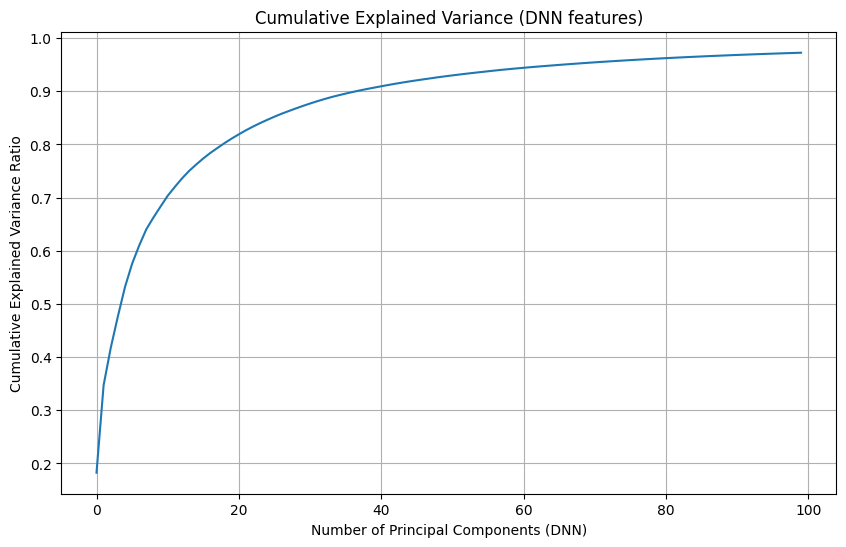

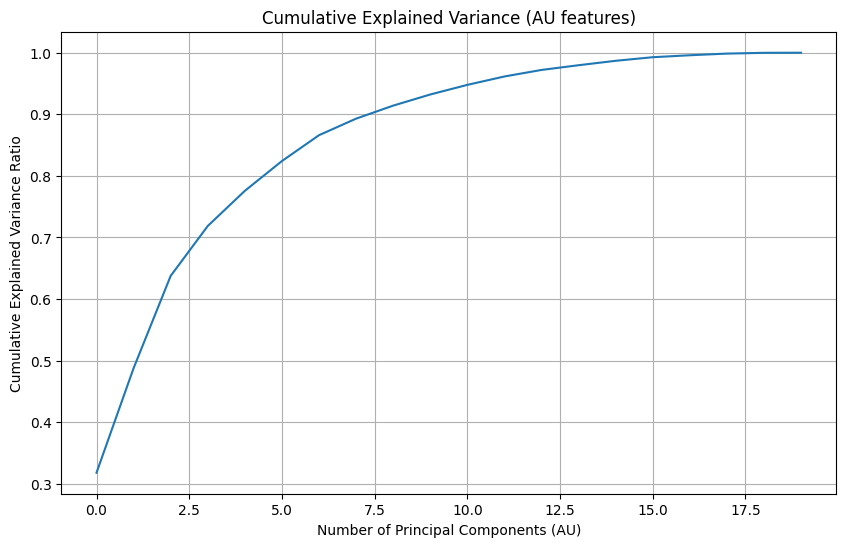

In [3]:
# --- 2. PCA the DNN (100) and AU (20) embeddings of target + ref1 + ref2 ---
df = add_dnn_pca(df, plot=True)
df = add_au_pca(df, plot=True)

In [4]:
# --- 3. Alignment features (computes all 9; we use only the 6 cosine sims by default) ---
if use_align:
    df = add_alignment_features(df)
    print("Using alignment columns:", ALIGN_USE)
    print("(manual_diff_* are computed but excluded from the default set — kept for [ref] rows.)")
else:
    print("CONFIG has no alignment features.")

# --- 3b. Listener<->speaker alignment: similarity to the identified active speaker (extended only) ---
if use_ls_align:
    df = add_listener_speaker_alignment(df)   # reads dnn_feature_reference.pickle + reference_behavior_results.zip
    cov = df[LS_ALIGN_COLS].notna().mean().round(2).to_dict()
    print("Added listener<->speaker alignment:", LS_ALIGN_COLS)
    print("non-NaN fraction (rest imputed with train medians):", cov)

Using alignment columns: ['au_align_ref1', 'au_align_ref2', 'au_align_ref1_ref2', 'dnn_align_ref1', 'dnn_align_ref2', 'dnn_align_ref1_ref2']
(manual_diff_* are computed but excluded from the default set — kept for [ref] rows.)


Added listener<->speaker alignment: ['ls_dnn_cos', 'ls_dnn_pear', 'ls_au_cos', 'ls_au_pear']
non-NaN fraction (rest imputed with train medians): {'ls_dnn_cos': 0.64, 'ls_dnn_pear': 0.64, 'ls_au_cos': 0.64, 'ls_au_pear': 0.64}


In [5]:
# --- 4. Split: train (unlabeled, for clustering) vs test (labeled) ---
train_df, test_df = split_train_test(df, label_df_3)
print(f"train (clustering): {len(train_df)} | test (labeled): {len(test_df)}")

# Clustering feature columns for this CONFIG (cosine alignment only)
feat_cols = TARGET_ONLY_COLS + (ALIGN_USE if use_align else [])
X_train_base = extract_and_combine_features(train_df, feat_cols)

# --- 5. Speaker block (extended only), imputed with TRAIN medians (no leakage) ---
if use_speaker:
    spk_medians = fit_speaker_imputer(train_df, groups["ac"])
    spk_train = speaker_block(train_df, groups["speaker"], groups["ac"], spk_medians)
    X_train_df = pd.concat([X_train_base, spk_train], axis=1)
else:
    X_train_df = X_train_base

# --- 5b. Listener<->speaker alignment block (extended only), TRAIN-median imputed ---
ls_medians = None
if use_ls_align:
    ls_medians = fit_ls_imputer(train_df)
    X_train_df = pd.concat([X_train_df, ls_align_block(train_df, ls_medians)], axis=1)

scaler = StandardScaler().fit(X_train_df)
X_train_scaled = scaler.transform(X_train_df)
print(f"X_train: {X_train_df.shape}")

train (clustering): 460 | test (labeled): 89
X_train: (460, 213)


## Choosing the number of clusters

`select_cluster_counts` reports the silhouette-optimal `k` per algorithm (diagnostic), with GMM BIC/AIC and
the dendrogram as cross-checks. The count actually used comes from `k_override` (default **3**), because
internal structure is weak (silhouette peaks at k=2) and clusters don't recover engagement (ARI≈0), making
`k` a presentation choice. (Clustering is unsupervised, so it is unaffected by `LABEL_SCHEME`.)

KMeans         silhouette  k=2:0.098  k=3:0.030  k=4:0.026  k=5:0.016  k=6:0.040  k=7:0.038  k=8:0.048  k=9:0.049  k=10:0.064  k=11:0.047
GMM            silhouette  k=2:0.098  k=3:0.030  k=4:0.026  k=5:0.016  k=6:0.040  k=7:0.038  k=8:0.048  k=9:0.049  k=10:0.064  k=11:0.047
Agglomerative  silhouette  k=2:0.084  k=3:0.086  k=4:0.047  k=5:0.048  k=6:0.055  k=7:0.058  k=8:0.052  k=9:0.056  k=10:0.058  k=11:0.060
Silhouette-optimal -> KMeans k=2, GMM n=2, Agglomerative k=3


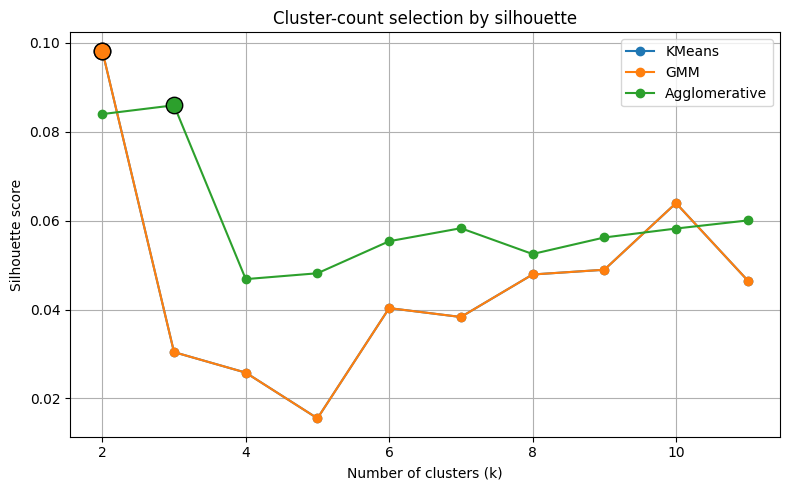

GMM BIC-optimal n = 2 | AIC-optimal n = 10


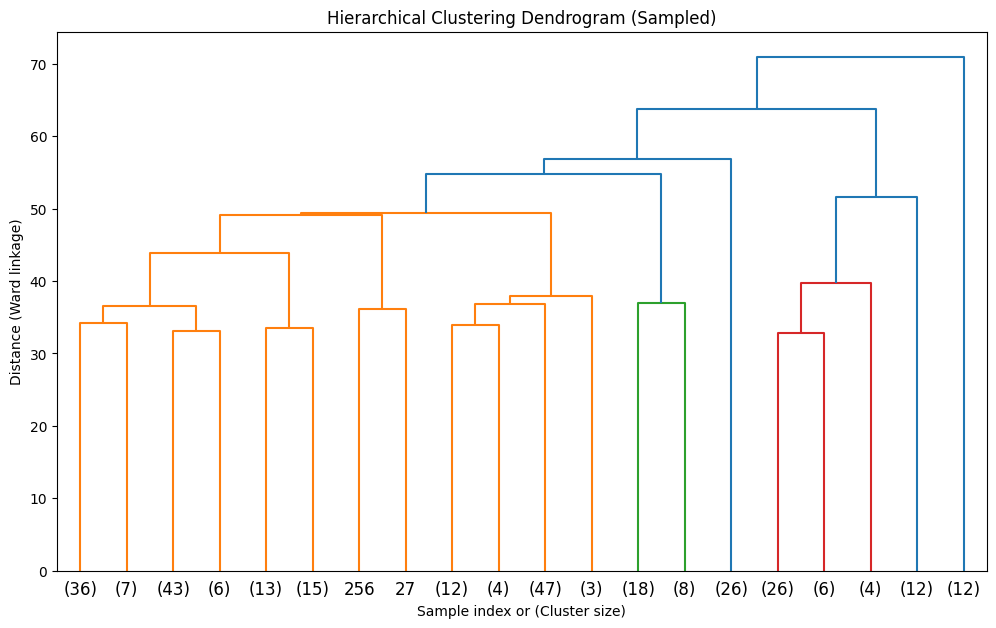

Silhouette-optimal would be {'kmeans': 2, 'gmm': 2, 'agg': 3}; using -> KMeans k=3, GMM n=3, Hierarchical k=3


In [6]:
best_k, sil_scores = select_cluster_counts(X_train_scaled, k_range=range(2, 12), plot=True)

bic, aic = gmm_bic_aic(X_train_scaled, n_range=range(2, 12))
print("GMM BIC-optimal n =", min(bic, key=bic.get), "| AIC-optimal n =", min(aic, key=aic.get))
plot_dendrogram(X_train_scaled)

ov = SETTINGS["k_override"]
k_kmeans = ov.get("kmeans", best_k["kmeans"])
n_gmm    = ov.get("gmm",    best_k["gmm"])
k_hier   = ov.get("agg",    best_k["agg"])
print(f"Silhouette-optimal would be {best_k}; using -> KMeans k={k_kmeans}, GMM n={n_gmm}, Hierarchical k={k_hier}")

In [7]:
# --- Fit KMeans / GMM / Agglomerative; attach cluster labels to train_df ---
kmeans_final, gmm_final, agg_final, labels = fit_clusterers(X_train_scaled, k_kmeans, n_gmm, k_hier)
for col, lab in labels.items():
    train_df[col] = lab

## Export representative clips per cluster

Copies 3 sample clips per cluster into `<out_root>/<algo>/<cluster>/` (reads the locally-unzipped
`filtered_clips/`) so the discovered behaviour groups can be inspected qualitatively.

In [8]:
ALGOS = {"kmean": "kmeans_cluster", "GMM": "gmm_cluster", "HIE": "hierarchical_cluster"}
_ = export_representative_clips(train_df, ALGOS, out_root=SETTINGS["out_root"],
                                clips_base="./filtered_clips", n_per_cluster=3)


=== kmean  (kmeans_cluster) ===
  Cluster 0: ['20220610-SP07F_clip_1095_1100', '20220722-SP07F_clip_1305_1310', '20230310-SP05F_clip_730_735']
  Cluster 1: ['20220916-SP07F_clip_5_10', '20220610-SP07F_clip_408_413', '20220204-SP04F_clip_1035_1040']
  Cluster 2: ['20211007-SP01F_clip_3030_3035', '20210616-SP02F_clip_849_854', '20220204-SP07F_clip_684_689']
  -> copied 6 clips to extended_cluster/kmean/ (3 missing in ./filtered_clips)

=== GMM  (gmm_cluster) ===
  Cluster 0: ['20220610-SP07F_clip_1095_1100', '20220722-SP07F_clip_1305_1310', '20230310-SP05F_clip_730_735']
  Cluster 1: ['20220916-SP07F_clip_5_10', '20220610-SP07F_clip_408_413', '20220204-SP04F_clip_1035_1040']
  Cluster 2: ['20211007-SP01F_clip_3030_3035', '20210616-SP02F_clip_849_854', '20220204-SP07F_clip_684_689']
  -> copied 6 clips to extended_cluster/GMM/ (3 missing in ./filtered_clips)

=== HIE  (hierarchical_cluster) ===
  Cluster 0: ['20221209-SP09M_clip_725_730', '20210616-SP03M_clip_390_395', '20210616-SP01F_cl

## Held-out engagement labels (under the chosen scheme)

The labeled segments are the held-out test set for the supervised comparison. Raw `majority_label_3` is
remapped via `LABEL_SCHEME`.

In [9]:
# Full labeled set (kept unfiltered for the scheme-sensitivity cell)
test_df_all = test_df.copy()
labeled_all = test_df_all.merge(label_df_3[["segment_id", "majority_label_3"]], on="segment_id", how="left")

# Apply the chosen scheme; drop rows it excludes ('confident_only' drops the uncertain middle)
y_all = apply_label_scheme(labeled_all["majority_label_3"], LABEL_SCHEME)
keep = y_all.notna().values
if not keep.all():
    print(f"LABEL_SCHEME={LABEL_SCHEME!r} excludes {int((~keep).sum())} segments (the dropped class).")
    test_df = test_df_all[keep].reset_index(drop=True)
else:
    test_df = test_df_all

test_eval = test_df.merge(label_df_3[["segment_id", "majority_label_3"]], on="segment_id", how="left")
y_true_test = apply_label_scheme(test_eval["majority_label_3"], LABEL_SCHEME).reset_index(drop=True)
engagement_labels = sorted(y_true_test.unique())
print(f"Held-out distribution ({LABEL_SCHEME}):", y_true_test.value_counts().to_dict())

Held-out distribution (3class): {'Active engagement': 44, 'Low engagement': 28, 'Disengagement': 17}


## Headline: does alignment / speaker help? (cross-validated)

**Full factorial** over the three add-on blocks on top of the target-only baseline — **O** = listener↔others
alignment, **LS** = listener↔speaker alignment, **S** = speaker — so every combination (incl. *all three*) is
shown. Stratified 5-fold CV, RandomForest (primary) + LogisticRegression, scaled inside a `Pipeline` (no
leakage); macro-F1 primary.

**Headline (RF):** **listener↔speaker alignment *alone* is the single best addition** (0.341 → **0.378**), above
listener↔others (0.326) and speaker (0.306). Crucially, **the blocks do not stack**: every richer combination
dilutes the gain (others+LS+speaker = 0.337 ≈ baseline) — adding dimensions costs more than the signal is worth
on 89 labels. So the finding is *the listener↔speaker relation carries the signal*, not *more features help*.
Honest caveats: gains within fold std (≈0.09); ~64% speaker coverage; `kmeans_ari` ≈ 0 (clusters don't recover
engagement). LR ranks others-align variants highest but its fits are degenerate (constant one-hot columns) — RF
is the primary estimator.

In [10]:
if use_align:
    import itertools
    y  = y_true_test.reset_index(drop=True)
    cv = make_cv()

    # --- feature blocks (combined factorially below) ---
    T  = extract_and_combine_features(test_df, TARGET_ONLY_COLS).reset_index(drop=True)        # listener nonverbal (baseline)
    O  = extract_and_combine_features(test_df, COSINE_ALIGN_COLS).reset_index(drop=True)       # listener<->others alignment (6)
    S  = (speaker_block(test_df, groups["speaker"], groups["ac"], spk_medians).reset_index(drop=True)
          if use_speaker else None)                                                            # speaker own features
    LS = (ls_align_block(test_df, ls_medians).reset_index(drop=True)
          if use_ls_align else None)                                                           # listener<->speaker alignment (4)

    # Full factorial: every subset of the available add-on blocks on top of target-only.
    addon_blocks = [("others-align", O)]
    if use_ls_align: addon_blocks.append(("listener<->speaker", LS))
    if use_speaker:  addon_blocks.append(("speaker", S))

    configs = [("baseline (target-only)", T)]
    for r in range(1, len(addon_blocks) + 1):
        for combo in itertools.combinations(addon_blocks, r):
            name = "+ " + " + ".join(n for n, _ in combo)
            configs.append((name, pd.concat([T] + [b for _, b in combo], axis=1)))

    # handles reused by later cells
    Xlab_target = T
    Xlab_align  = pd.concat([T, O], axis=1)
    spk_lab     = S
    ls_lab      = LS
    Xlab_ext    = pd.concat([T, O] + ([S] if use_speaker else []), axis=1)

    cv_report("Majority-class floor", lambda: DummyClassifier(strategy="most_frequent"), configs, y, cv)
    cv_report("RandomForest", rf, configs, y, cv)
    cv_report("LogisticRegression", lr, configs, y, cv)
    kmeans_ari(configs, y, k=len(engagement_labels))
else:
    print("CONFIG='base' has no alignment/speaker block to compare — skipping CV headline.")


=== Majority-class floor ===


  baseline (target-only)              acc=0.494±0.012   macroF1=0.220±0.004   (dim=166)
  + others-align                      acc=0.494±0.012   macroF1=0.220±0.004   (dim=172)
  + listener<->speaker                acc=0.494±0.012   macroF1=0.220±0.004   (dim=170)


  + speaker                           acc=0.494±0.012   macroF1=0.220±0.004   (dim=203)


  + others-align + listener<->speaker  acc=0.494±0.012   macroF1=0.220±0.004   (dim=176)
  + others-align + speaker            acc=0.494±0.012   macroF1=0.220±0.004   (dim=209)


  + listener<->speaker + speaker      acc=0.494±0.012   macroF1=0.220±0.004   (dim=207)
  + others-align + listener<->speaker + speaker  acc=0.494±0.012   macroF1=0.220±0.004   (dim=213)

=== RandomForest ===


...

  + others-align + speaker            acc=0.517±0.074   macroF1=0.364±0.115   (dim=209)


  + listener<->speaker + speaker      acc=0.505±0.057   macroF1=0.368±0.113   (dim=207)


  + others-align + listener<->speaker + speaker  acc=0.494±0.037   macroF1=0.337±0.065   (dim=213)

=== LogisticRegression ===
  baseline (target-only)              acc=0.471±0.071   macroF1=0.438±0.091   (dim=166)
  + others-align                      acc=0.516±0.060   macroF1=0.474±0.085   (dim=172)
  + listener<->speaker                acc=0.482±0.070   macroF1=0.447±0.094   (dim=170)


  + speaker                           acc=0.416±0.070   macroF1=0.392±0.066   (dim=203)
  + others-align + listener<->speaker  acc=0.516±0.034   macroF1=0.476±0.078   (dim=176)
  + others-align + speaker            acc=0.427±0.042   macroF1=0.395±0.066   (dim=209)
  + listener<->speaker + speaker      acc=0.427±0.055   macroF1=0.410±0.076   (dim=207)


  + others-align + listener<->speaker + speaker  acc=0.416±0.025   macroF1=0.392±0.048   (dim=213)

=== Adjusted Rand Index (KMeans k=3 vs true engagement) ===
  baseline (target-only)             ARI = -0.0108
  + others-align                     ARI = -0.0132
  + listener<->speaker               ARI = -0.0132
  + speaker                          ARI = -0.0237
  + others-align + listener<->speaker ARI = -0.0132
  + others-align + speaker           ARI = -0.0269
  + listener<->speaker + speaker     ARI = -0.0237
  + others-align + listener<->speaker + speaker ARI = -0.0237


## Why manual_diff was dropped + compact Head-and-Gesture encodings — extended only

The old `manual_diff_*` full-alignment block (`[ref]` rows) collapses relative to the compact cosine
encodings. `make_hg_blocks` adds a leakage-free 3-d Head-and-Gesture cosine alignment on top of the AU/CLIP
cosine sims. Confirms: drop `manual_diff_*`, keep cosine alignment + speaker.

In [11]:
if use_speaker:
    hg_cos, hg_dist, hg_grp = make_hg_blocks(train_df, test_df)
    Xlab_allcos     = pd.concat([Xlab_align, hg_cos], axis=1)            # AU/CLIP cosine + HG cosine
    Xlab_allcos_spk = pd.concat([Xlab_allcos, spk_lab], axis=1)
    # [ref] the dropped high-dim manual_diff full-alignment block
    Xlab_fulldiff     = extract_and_combine_features(test_df, TARGET_ONLY_COLS + ALIGN_COLS).reset_index(drop=True)
    Xlab_fulldiff_spk = pd.concat([Xlab_fulldiff, spk_lab], axis=1)

    hg_configs = [
        ("target-only (baseline)",                   Xlab_target),
        ("+ cosine-align (AU/CLIP)",                 Xlab_align),
        ("+ cosine-align + HG cosine",               Xlab_allcos),
        ("+ cosine-align + speaker",                 Xlab_ext),
        ("+ cosine-align + HG cosine + speaker",     Xlab_allcos_spk),
        ("[ref] full alignment w/ manual_diff",      Xlab_fulldiff),
        ("[ref] full alignment w/ manual_diff + spk", Xlab_fulldiff_spk),
    ]
    cv_report("RandomForest (manual_diff vs compact cosine)", rf, hg_configs, y, cv)
    cv_report("LogisticRegression (manual_diff vs compact cosine)", lr, hg_configs, y, cv)
else:
    print("This ablation is only meaningful for CONFIG='extended'.")


=== RandomForest (manual_diff vs compact cosine) ===


  target-only (baseline)              acc=0.459±0.084   macroF1=0.341±0.117   (dim=166)


  + cosine-align (AU/CLIP)            acc=0.482±0.070   macroF1=0.326±0.094   (dim=172)


  + cosine-align + HG cosine          acc=0.505±0.045   macroF1=0.352±0.066   (dim=175)


  + cosine-align + speaker            acc=0.517±0.074   macroF1=0.364±0.115   (dim=209)


  + cosine-align + HG cosine + speaker  acc=0.449±0.045   macroF1=0.279±0.090   (dim=212)


  [ref] full alignment w/ manual_diff  acc=0.415±0.052   macroF1=0.231±0.075   (dim=310)


  [ref] full alignment w/ manual_diff + spk  acc=0.448±0.054   macroF1=0.295±0.085   (dim=347)

=== LogisticRegression (manual_diff vs compact cosine) ===
  target-only (baseline)              acc=0.471±0.071   macroF1=0.438±0.091   (dim=166)
  + cosine-align (AU/CLIP)            acc=0.516±0.060   macroF1=0.474±0.085   (dim=172)
  + cosine-align + HG cosine          acc=0.516±0.034   macroF1=0.476±0.078   (dim=175)


  + cosine-align + speaker            acc=0.427±0.042   macroF1=0.395±0.066   (dim=209)
  + cosine-align + HG cosine + speaker  acc=0.405±0.041   macroF1=0.352±0.044   (dim=212)
  [ref] full alignment w/ manual_diff  acc=0.461±0.082   macroF1=0.381±0.127   (dim=310)


  [ref] full alignment w/ manual_diff + spk  acc=0.359±0.052   macroF1=0.313±0.082   (dim=347)


## Which features matter? (RandomForest importance + ANOVA F)

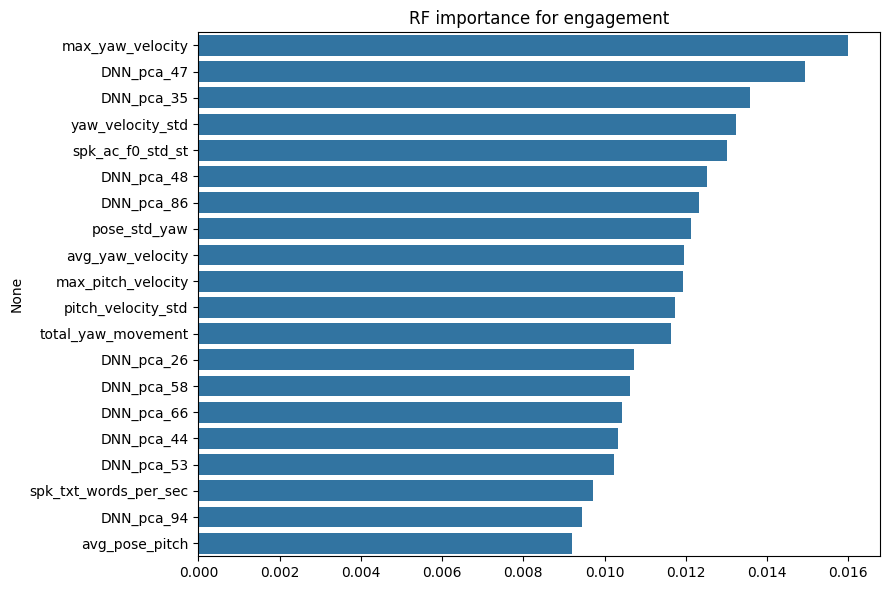

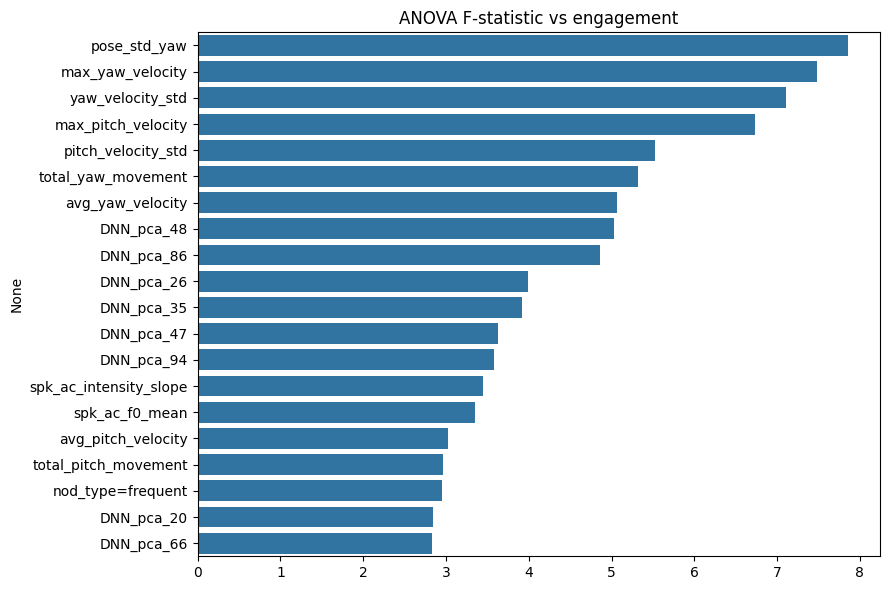

Top speaker-feature ranks within RF importance (1 = most important):
  #  5  spk_ac_f0_std_st
  # 18  spk_txt_words_per_sec
  # 32  spk_ac_final_rise_st
  # 53  spk_ac_intensity_slope
  # 55  spk_ac_hnr
  # 57  spk_ac_jitter
  # 73  spk_ac_f0_mean
  # 93  spk_txt_word_count
  #100  spk_ac_articulation_rate
  #103  spk_ac_f0_slope_st

Mean speaker features by engagement label:


,spk_ac_f0_std_st,spk_txt_words_per_sec,spk_ac_final_rise_st,spk_ac_intensity_slope,spk_ac_hnr,spk_ac_jitter,spk_ac_f0_mean,spk_txt_word_count
engagement,,,,,,,,
Active engagement,3.855,4.646,1.290,-3.339,10.912,0.021,172.675,11.250
Disengagement,3.354,4.775,-3.575,12.808,10.772,0.021,167.357,12.588
Low engagement,4.029,4.074,2.346,6.527,11.247,0.019,189.751,10.571



Listener<->speaker alignment ranks within RF importance:
  #139  ls_dnn_pear
  #152  ls_dnn_cos
  #154  ls_au_cos
  #161  ls_au_pear


In [12]:
if use_align:
    X_imp = Xlab_ext if use_speaker else Xlab_align
    if use_ls_align:
        X_imp = pd.concat([X_imp, ls_lab], axis=1)   # include listener<->speaker alignment in the ranking
    imp, anova = engagement_feature_importance(X_imp, y)

    if use_speaker:
        spk_mask = imp.index.str.startswith("spk_") | (imp.index == "speaker_overlap_sec")
        ranks = {f: int(np.where(imp.index == f)[0][0]) + 1 for f in imp.index[spk_mask]}
        print("Top speaker-feature ranks within RF importance (1 = most important):")
        for f, r in sorted(ranks.items(), key=lambda kv: kv[1])[:10]:
            print(f"  #{r:3d}  {f}")
        key_spk = [f for f in imp.index[spk_mask]][:8]
        print("\nMean speaker features by engagement label:")
        display(X_imp.assign(engagement=y).groupby("engagement")[key_spk].mean().round(3))

    if use_ls_align:
        ls_ranks = {f: int(np.where(imp.index == f)[0][0]) + 1 for f in LS_ALIGN_COLS if f in imp.index}
        print("\nListener<->speaker alignment ranks within RF importance:")
        for f, r in sorted(ls_ranks.items(), key=lambda kv: kv[1]):
            print(f"  #{r:3d}  {f}")
else:
    print("Feature-importance cell uses the engagement labels; run with alignment/extended CONFIG.")

### Feature-family importance + terminal pitch slope (report2 Fig. 2)

Two reads of "what matters", with an explicit caveat:
- **By family (impurity):** descriptive only — impurity importance is **biased toward high-cardinality blocks**
  (CLIP has ~100 dims). CLIP dominates here, yet the **listener↔speaker block — the best block in the CV
  ablation (Table 1) — ranks near the bottom.** So importance ≠ predictive value; **trust the CV ablation**.
- **Terminal pitch slope** (`spk_ac_final_rise_st`) by engagement class: a **descriptive correlate** (per-class
  means), the interpretable speaker cue from report2 — *not* a standalone predictor (speaker-only doesn't beat
  baseline out-of-sample, §Headline).

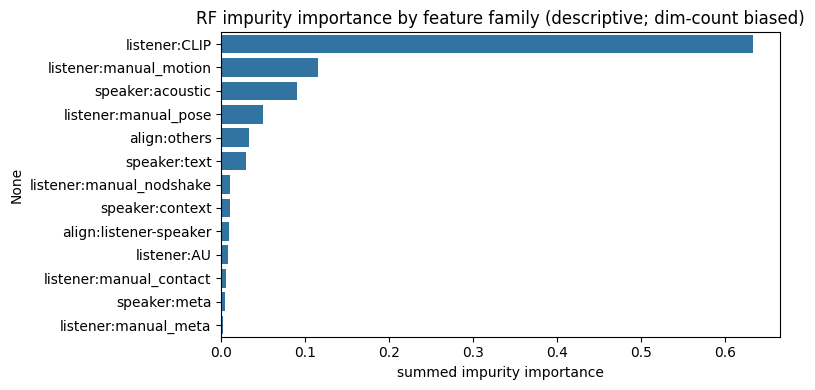

RF impurity importance by family (fraction):
listener:CLIP               0.633
listener:manual_motion      0.115
speaker:acoustic            0.090
listener:manual_pose        0.049
align:others                0.033
speaker:text                0.029
listener:manual_nodshake    0.011
speaker:context             0.010
align:listener-speaker      0.010
listener:AU                 0.008
listener:manual_contact     0.006
speaker:meta                0.005
listener:manual_meta        0.002

Caveat: impurity importance != predictive value — CLIP (~100 dims) dominates, yet the
listener<->speaker block (best in the CV ablation) ranks near the bottom. Trust Table 1.

Speaker prosody by engagement class (descriptive means — the interpretable correlate):


,spk_ac_final_rise_st,spk_ac_f0_mean,spk_ac_f0_std_st
engagement,,,
Active engagement,1.48,172.11,3.90
Disengagement,-3.58,167.36,3.35
Low engagement,2.63,190.47,4.09


Terminal pitch slope (spk_ac_final_rise_st): disengaged listeners are addressed with falling/flat
intonation. Descriptive class-mean difference, NOT a robust standalone predictor (speaker-only
does not beat baseline out-of-sample; see the Headline CV table).


In [13]:
if use_align:
    # (1) Importance aggregated by feature family (descriptive; dim-count biased)
    fam = family_importance(X_imp, y)
    print("RF impurity importance by family (fraction):")
    print((fam / fam.sum()).round(3).to_string())
    print("\nCaveat: impurity importance != predictive value — CLIP (~100 dims) dominates, yet the")
    print("listener<->speaker block (best in the CV ablation) ranks near the bottom. Trust Table 1.")

    # (2) Terminal pitch slope + key prosody by engagement class (report2 Fig. 2): a DESCRIPTIVE correlate
    if use_speaker:
        prosody = [c for c in ["spk_ac_final_rise_st", "spk_ac_f0_mean", "spk_ac_f0_std_st"] if c in test_df.columns]
        print("\nSpeaker prosody by engagement class (descriptive means — the interpretable correlate):")
        display(test_df.assign(engagement=y.values).groupby("engagement")[prosody].mean().round(2))
        print("Terminal pitch slope (spk_ac_final_rise_st): disengaged listeners are addressed with falling/flat")
        print("intonation. Descriptive class-mean difference, NOT a robust standalone predictor (speaker-only")
        print("does not beat baseline out-of-sample; see the Headline CV table).")
else:
    print("Run with an alignment/extended CONFIG for the family + prosody breakdown.")

## Extra finding — engagement target regrouping (sensitivity analysis)

The primary target is the 3-class annotation. The **reductions** below show *where* the predictable signal
lives (full labeled set, same leakage-free 5-fold CV; only the label mapping changes):

- **3class** (primary): near the majority floor; feature deltas within fold noise.
- **active_vs_rest** (Active vs Low+Disengaged): *"is the listener actively engaged?"* — **learnable** (RF
  macro-F1 ≈ 0.63), driven by the listener's **own** behaviour. This is the binary the annotators were
  reaching for (Active = the confident "engaged" call; Low = the unsure hedge).
- **engaged_vs_disengaged** (Active+Low vs Disengaged): *"any engagement vs none"* — **collapses** (81/19; the
  17 disengaged are unlearnable, disengaged F1 = 0).
- **confident_only** (Active vs Disengaged, the uncertain middle **dropped**): the cases annotators were sure
  about — still **fails** (≈ its majority floor) because the disengaged class is too small. → the binding
  constraint is **disengaged labels**, not the middle.

In [14]:
if use_align:
    from sklearn.model_selection import cross_val_score
    # Build feature matrices on the FULL labeled set (independent of the primary scheme's row-dropping)
    Xt_all = extract_and_combine_features(test_df_all, TARGET_ONLY_COLS).reset_index(drop=True)
    fsets = [("target-only", Xt_all)]
    if use_ls_align:
        fsets.append(("+ listener<->speaker align",
                      pd.concat([Xt_all, ls_align_block(test_df_all, ls_medians).reset_index(drop=True)], axis=1)))
    yraw = labeled_all["majority_label_3"].reset_index(drop=True)

    print(f"{'scheme':22s} {'feature set':27s} {'RF macroF1':>14s} {'RF acc':>8s} {'floor':>7s} {'n':>4s}")
    print("-" * 88)
    for sch in ["3class", "active_vs_rest", "engaged_vs_disengaged", "confident_only"]:
        ys = apply_label_scheme(yraw, sch)
        keep = ys.notna().values                       # confident_only drops the uncertain middle
        ys_k = ys[keep].reset_index(drop=True)
        floor = ys_k.value_counts(normalize=True).iloc[0]
        for fname, Xf in fsets:
            Xk = Xf[keep].reset_index(drop=True)
            f1 = cross_val_score(make_pipeline(StandardScaler(), rf()), Xk, ys_k, cv=make_cv(), scoring="f1_macro")
            ac = cross_val_score(make_pipeline(StandardScaler(), rf()), Xk, ys_k, cv=make_cv(), scoring="accuracy")
            print(f"{sch:22s} {fname:27s} {f1.mean():>7.3f}±{f1.std():<5.3f} {ac.mean():>8.3f} {floor:>7.3f} {len(ys_k):>4d}")
        print()
    print("3class: near floor; deltas within fold noise (engagement-as-annotated is hard at n=89).")
    print("active_vs_rest: 'actively engaged vs not' — learnable (~0.63), from the listener's own behaviour.")
    print("engaged_vs_disengaged: collapses (81/19; 17 disengaged unlearnable).")
    print("confident_only: drop the uncertain middle (Active vs Disengaged) — still fails; disengaged too rare.")
else:
    print("Run with CONFIG='extended' (or 'alignment') to compare label schemes.")

scheme                 feature set                     RF macroF1   RF acc   floor    n
----------------------------------------------------------------------------------------


3class                 target-only                   0.341±0.117    0.459   0.494   89


3class                 + listener<->speaker align    0.378±0.092    0.505   0.494   89



active_vs_rest         target-only                   0.634±0.062    0.641   0.506   89


active_vs_rest         + listener<->speaker align    0.581±0.116    0.597   0.506   89



engaged_vs_disengaged  target-only                   0.500±0.110    0.820   0.809   89


engaged_vs_disengaged  + listener<->speaker align    0.500±0.110    0.820   0.809   89



confident_only         target-only                   0.450±0.059    0.722   0.721   61


confident_only         + listener<->speaker align    0.439±0.038    0.706   0.721   61

3class: near floor; deltas within fold noise (engagement-as-annotated is hard at n=89).
active_vs_rest: 'actively engaged vs not' — learnable (~0.63), from the listener's own behaviour.
engaged_vs_disengaged: collapses (81/19; 17 disengaged unlearnable).
confident_only: drop the uncertain middle (Active vs Disengaged) — still fails; disengaged too rare.
